In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')
 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [28]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/ml/resource/"
file_name = "titanic.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

df = pd.read_csv(file_path)

df.head()

/Users/hyusoohi5/kdt_0900_khs/ml/resource/titanic.csv
True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


[공통 요구사항]

- 최종파일은 titinic_hgd.pdf의 형태로 압축하여 제출합니다.
- 시간 또는 기간이내에 미제출시 감점처리됩니다.
- 타이타닉 승객의 개인 및 탑승 정보(성별, 연령, 객실 등급 등)를 기반으로 생존 여부(survived: 생존 1 / 사망 0)를 예측하는 이진 분류(Binary Classification) 모델을 구축하고자 합니다.
- 입력(특성): 탑승객 인적/탑승 정보 (pclass, sex, age, sibsp, parch, fare, embarked 등)
- 출력(정답): 생존 여부 (1: 생존, 0: 사망)

[문제 1] 데이터 확인 및 EDA (10점)

1. 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치 탐색를 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)
2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)

In [29]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [30]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [31]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 기술통계량으로 데이터 값들을 확인해본 결과, 이상치 값을 아래와 같이 판단하였다.
- Age 컬럼의 std 값이 대략 0.83이다. 나이의 값이 정수가 아닌 1보다 작은 실수형으로 나타나므로 해당 값이 유효한지 확인이 필요하다.
- Fare 컬럼의 max 값이 512이다. 평균 값이 대략 32로 나타나는데, 해당 값이 유효한지 확인이 필요하다.

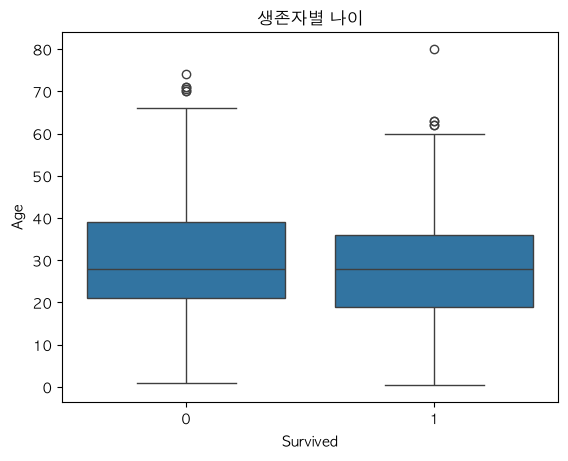

In [32]:
# 생존자별 나이
sns.boxplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")

plt.show()

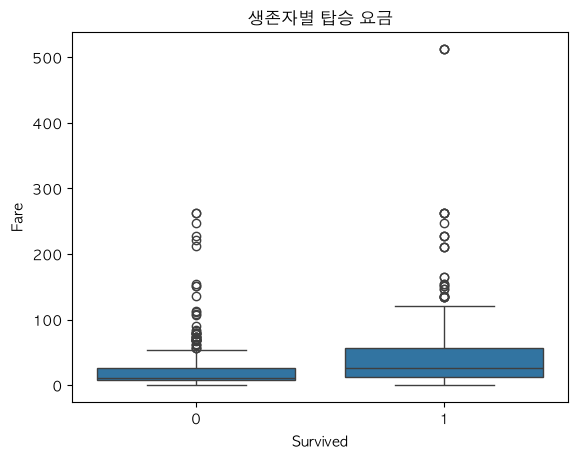

In [33]:
# 생존자별 객실 등급
sns.boxplot(titanic_df, x="Survived", y="Fare")
plt.title("생존자별 탑승 요금")

plt.show()

### boxplot 함수로 시각화해 본 결과
- Age 칼럼을 시각화해본 결과, 0.83은 이상치 후보로 판별되지만 영유아의 경우, 개월 수로 나이를 판별하기에 결측치가 아니라고 판단하였다.
- Fare 칼럼을 시각화해본 결과, 512은 명확한 이상치로 판별된다. 따라서 해당 값은 유효 여부를 판단하여 제거할 필요성이 있다고 판단하였다.

In [72]:
# 개수 확인
titanic_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

[문제 2] 다음 조건을 만족하도록 전처리를 설계하세요. (20점)

1. 수치형/범주형 변수를 구분하라. (5점)
2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)
3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)
4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)

In [34]:
# 수치형 데이터 : Age, SibSp, Parch, Fare
# 범주형 데이터 : Survived, Pclass, Sex, Embarked

In [35]:
# 결측치 처리 전략 : 
# 수치형 변수의 결측치는 이상치의 영향을 덜 받는 중앙값으로 대체하고, 범주형 변수는 최빈값을 활용해 보완한다. 
# 결측 비율이 과도하게 높은 변수는 활용 가능성 여부를 판별한 후 제거한다. 
# 이때 결측치 대체 기준은 학습 데이터에서 산출하고 테스트 데이터에는 동일한 기준을 적용하여 데이터 누수를 방지한다.

# Age 변수는 결측치가 존재하므로 중앙값으로 대체하였다. 
# 나이 데이터에는 고령 승객 등 극단값이 존재할 수 있어 평균보다 중앙값이 대표값으로 더 안정적이라고 판단하였다.

In [36]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22,1,0,7.2500
1,1,1,female,38,1,0,71.2833
2,1,3,female,26,0,0,7.9250


In [37]:
# one-hot-encoding 필요 여부
# Sex와 Embarked 컬럼의 값들이 문자형이므로, 이를 0 또는 1의 값으로 표현해야 하지만, Embarked는 종류가 3가지이므로 원-핫-인코딩이 불가능하다.
# 따라서 Embarked 컬럼은 테이블에서 제거하는 게 옳다고 판단하여, 다시 처음으로 돌아가 Embarked 컬럼까지 drop하도록 하겠다.

titanic_df["Sex"] = titanic_df["Sex"].map(lambda gender: {"male" : 0, "female" : 1}[gender])
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250


In [38]:
# 스케일링 : 수치형 변수 값들의 크기와 단위는 다르지만, 그 차이가 과도하게 크지 않다고 판단하여 스케일링은 표준화가 적합하다고 판별하였다.

[문제 3] 데이터 분리 및 검증 전략 (15점)

1. 학습/테스트 데이터를 분리하세요. (7점)
2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)

In [42]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

In [71]:
# X와 y를 구분하여 데이터 분리

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 6) (179, 6) (712,) (179,)


In [44]:
# 스케일링 (표준화) 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

[문제 4] 모델 학습 (20점)

1. 기본 모델 1개 이상: (예: Logistic Regression, Lasso, Ridge, RandomForest 등) (5점)
2. 모델 학습 및 예측까지 이어지는 전체 흐름과 각 단계별 핵심 코드를 작성하세요. (10점)
3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)

In [49]:
# 선택 모델 : Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [50]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [53]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

y_pred = lr.predict(X_test_scaled)

print(f"모델의 예측 확률 : {lr.predict_proba(X_test_scaled)[:10]}")
print(f"모델의 예측 값 : {y_pred[:10]}")
print(f"모델의 정답 : {y_test.values[:10]}")

모델의 예측 확률 : [[0.88924762 0.11075238]
 [0.95220275 0.04779725]
 [0.0483455  0.9516545 ]
 [0.88540341 0.11459659]
 [0.89899462 0.10100538]
 [0.9331302  0.0668698 ]
 [0.04301364 0.95698636]
 [0.27704107 0.72295893]
 [0.79477686 0.20522314]
 [0.41978737 0.58021263]]
모델의 예측 값 : [0 0 1 0 0 0 1 1 0 1]
모델의 정답 : [0 0 1 0 0 1 1 1 0 0]


In [73]:
# 파라미터는 모델이 학습(fit)하면서 데이터로부터 스스로 찾는 값이고, 하이퍼파라미터는 학습(fit) 전에 특정 메서드와 수치를 넣어 임의로 설정해주는 값이다.
# 구분을 하자면, 선택한 모델 'Logistic Regression'에서 파라미터는 'coef_'이고, 하이퍼파라미터는 'max_iter'이다.

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print("테스트 정확도:", accuracy_score(y_test, y_pred))

테스트 정확도: 0.7821229050279329


[문제 5] 평가 및 리포트 (20점)

1. Accuracy, Precision, Recall, F1 중 최소 2개 이상 사용하여 모델을 평가하세요. (10점)
2. Confusion Matrix 해석하세요. (5점)
3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)

In [66]:
from sklearn.metrics import accuracy_score, recall_score

In [74]:
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Recall
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

print(f"훈련 정확도 : {train_accuracy}")
print(f"테스트 정확도 : {test_accuracy}")

print(f"훈련 재현율 : {train_recall}")
print(f"테스트 재현율 : {test_recall}")

훈련 정확도 : 0.797752808988764
테스트 정확도 : 0.7821229050279329
훈련 재현율 : 0.717948717948718
테스트 재현율 : 0.7246376811594203


Text(0.5, 1.0, 'confusion matrix')

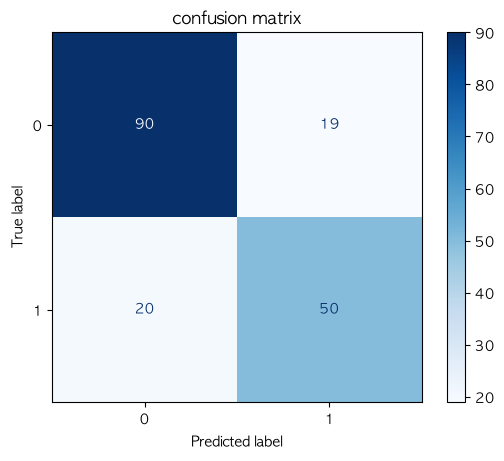

In [70]:
# Confusion Matrix 해석

cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("confusion matrix")

[문제 6] 최종 제출물 구성 (10점)

1. 데이터 요약(EDA 결과 핵심 3가지)하여 서술하세요. (3점)
2. 전처리 전략 요약(결측/인코딩/스케일링)하여 서술하세요. (3점)
3. 모델 선택 이유와 학습 설정(튜닝 포함)을 요약하여 서술하세요. (2점)
4. 최종 성능 지표 및 해석과 개선 아이디어 1개 이상 서술하세요. (2점)